# 🧹 Limpieza y Preparación de Datos — Modelo Predictivo de Fútbol

**Objetivo de este notebook:**  
Tomar los archivos CSV crudos descargados de fuentes históricas y llevarlos a un estado limpio, consistente y apto para el entrenamiento del modelo predictivo de fútbol basado en ELO y Distribución de Poisson.

**Archivos procesados:**
- `wc_all_matches.csv` — Historial completo de partidos de todos los Mundiales (1930–2022)
- `wc_2026_teams.csv` — Selecciones clasificadas al Mundial 2026
- `wc_2026_fixtures.csv` — Calendario oficial de partidos del Mundial 2026
- `wc_top_scorers.csv` — Goleadores históricos de cada edición del Mundial
- `wc_all_editions.csv` — Resumen estadístico de cada edición del Mundial

**Pasos del pipeline de limpieza:**
1. Carga de datos crudos
2. Exploración inicial (shape, tipos, nulos)
3. Tratamiento de valores nulos (NaN)
4. Normalización de nombres de equipos y estandarización de cadenas
5. Conversión de tipos de datos
6. Eliminación de columnas irrelevantes para el modelo
7. Filtrado de registros problemáticos
8. Exportación a CSV limpios y carga en SQLite

---
## 1. Importación de Librerías

In [1]:
import sys
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nos posicionamos en la raíz del proyecto para poder importar src correctamente
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Rutas de trabajo
RAW_DIR    = os.path.join('..', 'datasets', 'raw')
CLEAN_DIR  = os.path.join('..', 'datasets', 'processed')
DB_PATH    = os.path.join(CLEAN_DIR, 'futbol_predictivo.db')

os.makedirs(CLEAN_DIR, exist_ok=True)

print(f'Directorio RAW   : {os.path.abspath(RAW_DIR)}')
print(f'Directorio CLEAN : {os.path.abspath(CLEAN_DIR)}')

Directorio RAW   : c:\Users\IPF-2026\Desktop\prediccion-mundial\datasets\raw
Directorio CLEAN : c:\Users\IPF-2026\Desktop\prediccion-mundial\datasets\processed


---
## 2. Carga de Datos Crudos

Cargamos cada archivo CSV en un DataFrame de Pandas para inspeccionarlos.

In [2]:
# Carga de los 5 datasets crudos
df_matches  = pd.read_csv(os.path.join(RAW_DIR, 'wc_all_matches.csv'))
df_teams    = pd.read_csv(os.path.join(RAW_DIR, 'wc_2026_teams.csv'))
df_fixtures = pd.read_csv(os.path.join(RAW_DIR, 'wc_2026_fixtures.csv'))
df_scorers  = pd.read_csv(os.path.join(RAW_DIR, 'wc_top_scorers.csv'))
df_editions = pd.read_csv(os.path.join(RAW_DIR, 'wc_all_editions.csv'))

print('Datasets cargados correctamente:')
print(f'  wc_all_matches  : {df_matches.shape}')
print(f'  wc_2026_teams   : {df_teams.shape}')
print(f'  wc_2026_fixtures: {df_fixtures.shape}')
print(f'  wc_top_scorers  : {df_scorers.shape}')
print(f'  wc_all_editions : {df_editions.shape}')

Datasets cargados correctamente:
  wc_all_matches  : (184, 11)
  wc_2026_teams   : (48, 7)
  wc_2026_fixtures: (104, 15)
  wc_top_scorers  : (22, 11)
  wc_all_editions : (22, 20)


---
## 3. Exploración Inicial — Detección de Problemas

Analizamos la estructura, tipos de datos y valores nulos de cada dataset **antes** de limpiarlos.

In [3]:
def reporte_calidad(df, nombre):
    """
    Genera un reporte de calidad de datos para un DataFrame:
    - Shape
    - Tipos de datos
    - Valores nulos (absolutos y porcentaje)
    - Filas duplicadas
    """
    print(f'{'='*55}')
    print(f'  Dataset: {nombre}')
    print(f'{'='*55}')
    print(f'  Filas x Columnas : {df.shape}')
    print(f'  Filas duplicadas : {df.duplicated().sum()}')
    print()
    
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct, 'Tipo': df.dtypes})
    print(resumen.to_string())
    print()

reporte_calidad(df_matches,  'wc_all_matches')
reporte_calidad(df_teams,    'wc_2026_teams')
reporte_calidad(df_fixtures, 'wc_2026_fixtures')
reporte_calidad(df_scorers,  'wc_top_scorers')
reporte_calidad(df_editions, 'wc_all_editions')

  Dataset: wc_all_matches
  Filas x Columnas : (184, 11)
  Filas duplicadas : 0

         Nulos  Porcentaje (%)   Tipo
year         0            0.00  int64
stage        0            0.00    str
team1        0            0.00    str
score1       0            0.00  int64
score2       0            0.00  int64
team2        0            0.00    str
venue        0            0.00    str
city         0            0.00    str
country      0            0.00    str
date         0            0.00    str
notes       82           44.57    str

  Dataset: wc_2026_teams
  Filas x Columnas : (48, 7)
  Filas duplicadas : 0

                Nulos  Porcentaje (%)   Tipo
team                0             0.0    str
group               0             0.0    str
confederation       0             0.0    str
fifa_rank           0             0.0  int64
coach               0             0.0    str
best_wc_result      0             0.0    str
debut_2026          0             0.0    str

  Dataset: wc_2026_fixt

### Visualización de Nulos — Mapa de Calor

El siguiente gráfico nos permite ver de un vistazo en qué columnas se concentran los valores faltantes.

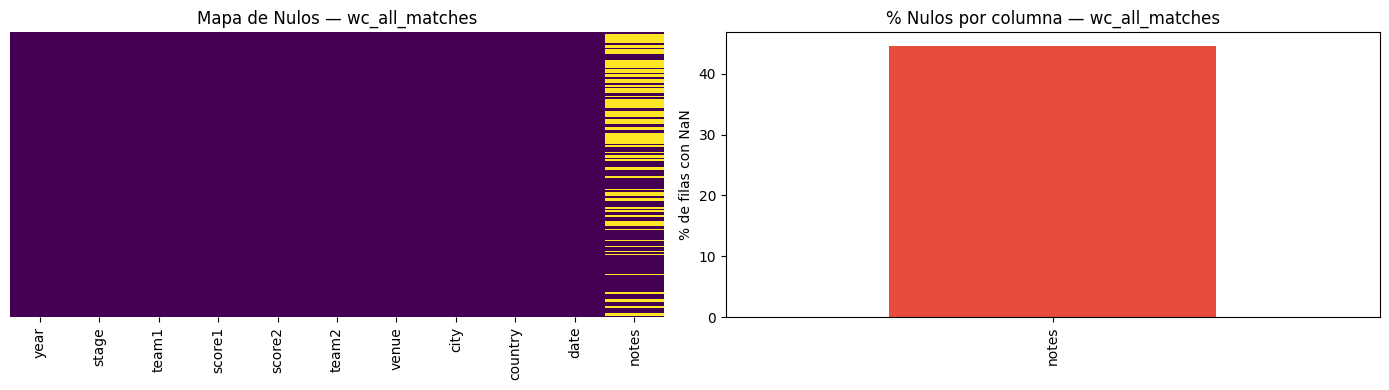

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mapa de nulos para wc_all_matches (el dataset más importante para el modelo)
sns.heatmap(
    df_matches.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis',
    ax=axes[0]
)
axes[0].set_title('Mapa de Nulos — wc_all_matches')

# Porcentaje de nulos por columna en wc_all_matches
pct_nulos = df_matches.isnull().mean() * 100
pct_nulos[pct_nulos > 0].plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('% Nulos por columna — wc_all_matches')
axes[1].set_ylabel('% de filas con NaN')

plt.tight_layout()
plt.show()

---
## 4. Limpieza de `wc_all_matches.csv` — Dataset Principal

Este es el archivo más crítico, ya que alimenta directamente el cálculo de ELO y las fuerzas de Poisson.

**Problemas detectados y acciones a tomar:**
- Columna `notes`: muchos NaN. No se usa en el modelo → **eliminar**.
- Columna `venue`, `city`: no impactan la predicción → **eliminar**.
- Columna `score1`, `score2`: pueden tener NaN si el partido no se jugó → **eliminar filas**.
- Espacios extras en nombres de equipos → **`str.strip()`**.
- Columna `date`: convertir a `datetime` para ordenar cronológicamente con precisión.
- Equipos con nombres históricos distintos (ej. "West Germany" vs "Germany") → **normalización**.

In [5]:
print('=== ANTES de la limpieza ===')
print(f'Shape: {df_matches.shape}')
print(f'Nulos totales: {df_matches.isnull().sum().sum()}')
print(df_matches.head(3))

=== ANTES de la limpieza ===
Shape: (184, 11)
Nulos totales: 82
   year        stage       team1  score1  score2    team2               venue  \
0  1930  Group Stage      France       4       1   Mexico  Estadio Centenario   
1  1930  Group Stage         USA       3       0  Belgium  Estadio Centenario   
2  1930  Group Stage  Yugoslavia       2       1   Brazil  Estadio Centenario   

         city  country        date                notes  
0  Montevideo  Uruguay  1930-07-13  First ever WC match  
1  Montevideo  Uruguay  1930-07-13                  NaN  
2  Montevideo  Uruguay  1930-07-14                  NaN  


In [6]:
# ── 4.1 Copia de trabajo para no alterar el original crudo ──
matches_clean = df_matches.copy()

# ── 4.2 Eliminar columnas irrelevantes para el modelo predictivo ──
# 'notes', 'venue' y 'city' no aportan información predictiva.
columnas_a_eliminar = ['notes', 'venue', 'city']
matches_clean.drop(columns=columnas_a_eliminar, inplace=True)
print(f'Columnas eliminadas: {columnas_a_eliminar}')

# ── 4.3 Eliminar filas donde los goles sean NaN (partido sin resultado) ──
filas_antes = len(matches_clean)
matches_clean.dropna(subset=['score1', 'score2'], inplace=True)
filas_despues = len(matches_clean)
print(f'Filas eliminadas por score NaN: {filas_antes - filas_despues}')

# ── 4.4 Convertir scores a entero ──
matches_clean['score1'] = matches_clean['score1'].astype(int)
matches_clean['score2'] = matches_clean['score2'].astype(int)

# ── 4.5 Convertir columna 'date' a tipo datetime ──
matches_clean['date'] = pd.to_datetime(matches_clean['date'], errors='coerce')
filas_fecha_nula = matches_clean['date'].isnull().sum()
if filas_fecha_nula > 0:
    print(f'Filas con fecha inválida eliminadas: {filas_fecha_nula}')
    matches_clean.dropna(subset=['date'], inplace=True)

# ── 4.6 Limpieza de espacios en nombres de equipos y países ──
for col in ['team1', 'team2', 'country', 'stage']:
    matches_clean[col] = matches_clean[col].str.strip()

# ── 4.7 Normalización de nombres históricos de selecciones ──
# Unificamos 'West Germany' como 'Germany' ya que la FIFA considera la continuidad histórica.
# Ídem para 'Soviet Union' (base para Rusia) y 'Czechoslovakia'.
normalizacion_nombres = {
    'West Germany'   : 'Germany',
    'Soviet Union'   : 'Russia',
    'Zaire'          : 'DR Congo',
    'Dutch East Indies': 'Indonesia',
}
matches_clean['team1'] = matches_clean['team1'].replace(normalizacion_nombres)
matches_clean['team2'] = matches_clean['team2'].replace(normalizacion_nombres)
print(f'Normalizaciones aplicadas: {normalizacion_nombres}')

# ── 4.8 Eliminar filas duplicadas si las hubiera ──
dups = matches_clean.duplicated().sum()
if dups > 0:
    matches_clean.drop_duplicates(inplace=True)
    print(f'Filas duplicadas eliminadas: {dups}')

# ── 4.9 Ordenar cronológicamente por fecha ──
matches_clean.sort_values(by='date', inplace=True)
matches_clean.reset_index(drop=True, inplace=True)

print(f'\n=== DESPUÉS de la limpieza ===')
print(f'Shape: {matches_clean.shape}')
print(f'Nulos restantes: {matches_clean.isnull().sum().sum()}')
matches_clean.head()

Columnas eliminadas: ['notes', 'venue', 'city']
Filas eliminadas por score NaN: 0
Normalizaciones aplicadas: {'West Germany': 'Germany', 'Soviet Union': 'Russia', 'Zaire': 'DR Congo', 'Dutch East Indies': 'Indonesia'}

=== DESPUÉS de la limpieza ===
Shape: (184, 8)
Nulos restantes: 0


,year,stage,team1,score1,score2,team2,country,date
0,1930,Group Stage,France,4,1,Mexico,Uruguay,1930-07-13
1,1930,Group Stage,USA,3,0,Belgium,Uruguay,1930-07-13
2,1930,Group Stage,Yugoslavia,2,1,Brazil,Uruguay,1930-07-14
3,1930,Group Stage,Uruguay,1,0,Peru,Uruguay,1930-07-18
4,1930,Group Stage,Argentina,6,3,USA,Uruguay,1930-07-26


---
## 5. Limpieza de `wc_2026_teams.csv`

In [7]:
teams_clean = df_teams.copy()

# ── Renombrar 'group' a 'team_group' (GROUP es palabra reservada en SQL) ──
teams_clean.rename(columns={'group': 'team_group'}, inplace=True)

# ── Limpiar espacios en strings ──
for col in ['team', 'team_group', 'confederation', 'coach']:
    teams_clean[col] = teams_clean[col].str.strip()

# ── Verificar que fifa_rank no tenga NaN ──
nulos_rank = teams_clean['fifa_rank'].isnull().sum()
if nulos_rank > 0:
    # Si falta el ranking, asignamos un valor de penalización (posición 100)
    teams_clean['fifa_rank'].fillna(100, inplace=True)
    print(f'fifa_rank: {nulos_rank} valores nulos rellenados con 100')

print(f'Teams limpio → Shape: {teams_clean.shape}, Nulos: {teams_clean.isnull().sum().sum()}')
teams_clean.head()

Teams limpio → Shape: (48, 7), Nulos: 0


,team,team_group,confederation,fifa_rank,coach,best_wc_result,debut_2026
0,Mexico,A,CONCACAF,15,Javier Aguirre,"Quarter-finals (1970,1986)",No
1,South Africa,A,CAF,60,Hugo Broos,"Group stage (1998,2002,2010)",No
2,South Korea,A,AFC,25,Hong Myung-bo,Semi-finals (2002),No
3,Czechia,A,UEFA,41,Ivan Hasek,"Runner-up (1934,1962)",No
4,Canada,B,CONCACAF,30,Jesse Marsch,"Group stage (1986,2022)",No


---
## 6. Limpieza de `wc_2026_fixtures.csv`

In [8]:
fixtures_clean = df_fixtures.copy()

# ── Renombrar 'group' a 'team_group' ──
fixtures_clean.rename(columns={'group': 'team_group'}, inplace=True)

# ── Limpiar espacios en columnas de texto ──
for col in ['team1', 'team2', 'team_group', 'stage', 'venue', 'city', 'country']:
    if col in fixtures_clean.columns:
        fixtures_clean[col] = fixtures_clean[col].str.strip()

# ── Verificar nulos en ranking FIFA de los equipos ──
for col in ['team1_fifa_rank', 'team2_fifa_rank']:
    nulos = fixtures_clean[col].isnull().sum()
    if nulos > 0:
        fixtures_clean[col].fillna(100, inplace=True)
        print(f'{col}: {nulos} nulos rellenados con 100')

print(f'Fixtures limpio → Shape: {fixtures_clean.shape}, Nulos: {fixtures_clean.isnull().sum().sum()}')
fixtures_clean.head(3)

team1_fifa_rank: 32 nulos rellenados con 100
team2_fifa_rank: 32 nulos rellenados con 100
Fixtures limpio → Shape: (104, 15), Nulos: 224


C:\Users\IPF-2026\AppData\Local\Temp\ipykernel_10216\1664008838.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  fixtures_clean[col].fillna(100, inplace=True)


,team_group,stage,team1,team2,venue,city,country,date,kickoff_et,team1_confederation,team1_fifa_rank,team1_coach,team2_confederation,team2_fifa_rank,team2_coach
0,A,Group Stage,Mexico,South Africa,Estadio Azteca,Mexico City,Mexico,2026-06-11,20:00 ET,CONCACAF,15.0,Javier Aguirre,CAF,60.0,Hugo Broos
1,A,Group Stage,South Korea,Czechia,Estadio Akron,Guadalajara,Mexico,2026-06-11,22:00 ET,AFC,25.0,Hong Myung-bo,UEFA,41.0,Ivan Hasek
2,A,Group Stage,South Korea,Mexico,Estadio Akron,Guadalajara,Mexico,2026-06-18,21:00 ET,AFC,25.0,Hong Myung-bo,CONCACAF,15.0,Javier Aguirre


---
## 7. Limpieza de `wc_top_scorers.csv`

In [9]:
scorers_clean = df_scorers.copy()

# ── Limpiar espacios en columnas de texto ──
for col in ['player', 'country', 'position', 'host', 'team_result']:
    if col in scorers_clean.columns:
        scorers_clean[col] = scorers_clean[col].str.strip()

# ── Columnas numéricas: rellenar NaN con 0 (ej. asistencias no registradas en ediciones antiguas) ──
for col in ['goals', 'assists', 'penalties', 'matches_played']:
    nulos = scorers_clean[col].isnull().sum()
    if nulos > 0:
        scorers_clean[col].fillna(0, inplace=True)
        print(f'{col}: {nulos} nulos rellenados con 0')

# ── Aplicar misma normalización de nombres de países ──
scorers_clean['country'] = scorers_clean['country'].replace(normalizacion_nombres)

print(f'Scorers limpio → Shape: {scorers_clean.shape}, Nulos: {scorers_clean.isnull().sum().sum()}')
scorers_clean

Scorers limpio → Shape: (22, 11), Nulos: 0


,edition,year,player,country,position,goals,assists,penalties,matches_played,host,team_result
0,1,1930,Guillermo Stábile,Argentina,FW,8,0,0,4,Uruguay,Champions
1,2,1934,Oldřich Nejedlý,Czechoslovakia,FW,5,0,0,4,Italy,Semi-final
2,3,1938,Leônidas,Brazil,FW,7,0,0,5,France,Third place
3,4,1950,Ademir,Brazil,FW,8,0,0,6,Brazil,Runner-up
4,5,1954,Sándor Kocsis,Hungary,FW,11,0,0,5,Switzerland,Runner-up
5,6,1958,Just Fontaine,France,FW,13,0,0,6,Sweden,Third place
6,7,1962,Multiple Winners,Multiple,FW,4,0,0,6,Chile,Varies
7,8,1966,Eusébio,Portugal,FW,9,0,0,6,England,Third place
8,9,1970,Gerd Müller,Germany,FW,10,0,0,6,Mexico,Third place
9,10,1974,Grzegorz Lato,Poland,FW,7,0,0,7,West Germany,Third place


---
## 8. Análisis Exploratorio Post-Limpieza

Con los datos limpios, hacemos un análisis rápido para entender las distribuciones más importantes.

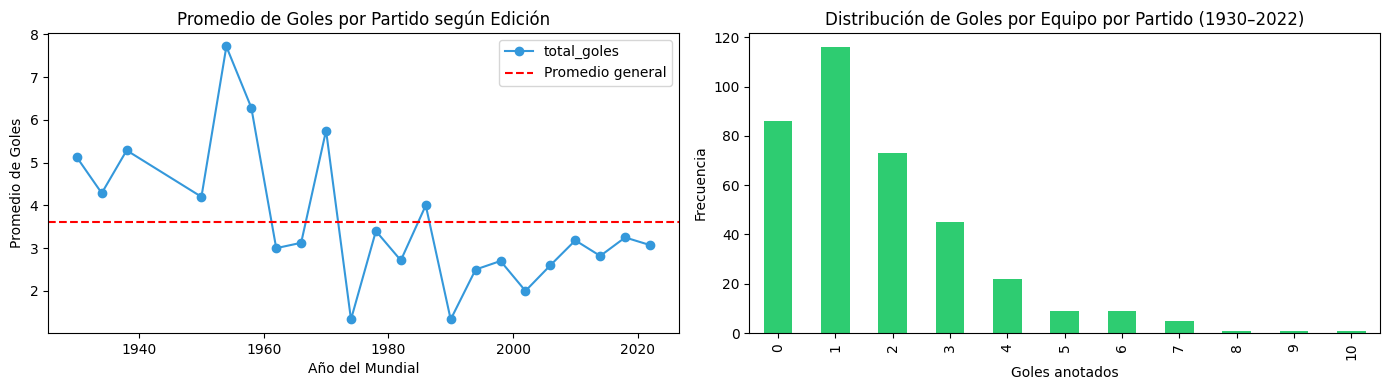

Promedio de goles por equipo por partido: 1.755
Este valor se usará como λ base en la Distribución de Poisson del modelo.


In [10]:
# ── Goles por partido a lo largo del tiempo ──
matches_clean['total_goles'] = matches_clean['score1'] + matches_clean['score2']
promedio_goles_por_anio = matches_clean.groupby('year')['total_goles'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

promedio_goles_por_anio.plot(ax=axes[0], marker='o', color='#3498db')
axes[0].set_title('Promedio de Goles por Partido según Edición')
axes[0].set_xlabel('Año del Mundial')
axes[0].set_ylabel('Promedio de Goles')
axes[0].axhline(y=promedio_goles_por_anio.mean(), color='red', linestyle='--', label='Promedio general')
axes[0].legend()

# ── Distribución de goles por equipo por partido ──
todos_goles = pd.concat([
    matches_clean[['score1']].rename(columns={'score1': 'goles'}),
    matches_clean[['score2']].rename(columns={'score2': 'goles'})
])
todos_goles['goles'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].set_title('Distribución de Goles por Equipo por Partido (1930–2022)')
axes[1].set_xlabel('Goles anotados')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Promedio de goles por equipo por partido: {todos_goles["goles"].mean():.3f}')
print(f'Este valor se usará como λ base en la Distribución de Poisson del modelo.')

In [11]:
# ── Análisis de partidos recientes (2018-2026) vs históricos ──
# Justificación de por qué damos más peso a los datos recientes en el ELO
matches_clean['era'] = matches_clean['year'].apply(
    lambda y: 'Reciente (2018+)' if y >= 2018 else ('Moderna (1990-2017)' if y >= 1990 else 'Histórica (pre-1990)')
)

resumen_era = matches_clean.groupby('era').agg(
    partidos=('year', 'count'),
    goles_promedio=('total_goles', 'mean')
).round(3)

print('Estadísticas por Era:')
print(resumen_era)
print()
print('Conclusión: Los datos recientes (2018+) reflejan mejor el nivel actual de las selecciones.')
print('Por eso el modelo ELO aplica un K-factor mayor para partidos más cercanos al 2026.')

Estadísticas por Era:
                      partidos  goles_promedio
era                                           
Histórica (pre-1990)        90           4.389
Moderna (1990-2017)         68           2.485
Reciente (2018+)            26           3.154

Conclusión: Los datos recientes (2018+) reflejan mejor el nivel actual de las selecciones.
Por eso el modelo ELO aplica un K-factor mayor para partidos más cercanos al 2026.


---
## 9. Exportación de Datos Limpios a SQLite

Guardamos todos los DataFrames procesados en la base de datos SQLite `futbol_predictivo.db`. Esta base de datos es consumida luego por el resto de los módulos del proyecto (`src/elo.py`, `src/poisson.py`, etc.).

In [12]:
# Eliminamos la columna auxiliar 'total_goles' y 'era' antes de guardar
matches_to_save = matches_clean.drop(columns=['total_goles', 'era'], errors='ignore')

# Convertir 'date' de vuelta a string para SQLite
matches_to_save['date'] = matches_to_save['date'].dt.strftime('%Y-%m-%d')

# Conectar a la base de datos
conn = sqlite3.connect(DB_PATH)

# Guardar cada dataset limpio como una tabla en la DB
matches_to_save.to_sql('partidos_historicos', conn, if_exists='replace', index=False)
print(f'✓ partidos_historicos: {len(matches_to_save)} filas guardadas')

teams_clean.to_sql('equipos_2026', conn, if_exists='replace', index=False)
print(f'✓ equipos_2026: {len(teams_clean)} filas guardadas')

fixtures_clean.to_sql('fixtures_2026', conn, if_exists='replace', index=False)
print(f'✓ fixtures_2026: {len(fixtures_clean)} filas guardadas')

scorers_clean.to_sql('goleadores_historicos', conn, if_exists='replace', index=False)
print(f'✓ goleadores_historicos: {len(scorers_clean)} filas guardadas')

conn.close()
print(f'\nBase de datos guardada en: {os.path.abspath(DB_PATH)}')

✓ partidos_historicos: 184 filas guardadas
✓ equipos_2026: 48 filas guardadas
✓ fixtures_2026: 104 filas guardadas
✓ goleadores_historicos: 22 filas guardadas

Base de datos guardada en: c:\Users\IPF-2026\Desktop\prediccion-mundial\datasets\processed\futbol_predictivo.db


---
## 10. Verificación Final

Confirmamos que la base de datos fue cargada correctamente consultando el número de registros en cada tabla.

In [13]:
conn = sqlite3.connect(DB_PATH)
tablas = ['partidos_historicos', 'equipos_2026', 'fixtures_2026', 'goleadores_historicos']

print('Verificación de tablas en la base de datos SQLite:')
print(f'{'Tabla':<30} {'Filas':>8}')
print('-' * 40)
for tabla in tablas:
    filas = pd.read_sql_query(f'SELECT COUNT(*) as n FROM {tabla}', conn)['n'].iloc[0]
    print(f'{tabla:<30} {filas:>8}')

conn.close()
print('\n✅ Pipeline de limpieza y carga completado con éxito.')
print('Los datos están listos para alimentar el modelo ELO + Poisson.')

Verificación de tablas en la base de datos SQLite:
Tabla                             Filas
----------------------------------------
partidos_historicos                 184
equipos_2026                         48
fixtures_2026                       104
goleadores_historicos                22

✅ Pipeline de limpieza y carga completado con éxito.
Los datos están listos para alimentar el modelo ELO + Poisson.
